In [ ]:
!unzip -q Dataset.zip -d dataset_pothole

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.2 MB/s eta 0:00:00


In [ ]:
import os
import yaml

# Cek struktur folder dataset
dataset_path = '/content/dataset_pothole'

print("=" * 50)
print("  STRUKTUR DATASET")
print("=" * 50)

for folder in ['train', 'valid', 'test']:
    img_path = os.path.join(dataset_path, folder, 'images')
    lbl_path = os.path.join(dataset_path, folder, 'labels')
    if os.path.exists(img_path):
        jumlah_img = len(os.listdir(img_path))
        jumlah_lbl = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0
        print(f"  {folder:<10} → {jumlah_img} gambar | {jumlah_lbl} label")

print("=" * 50)

# Baca data.yaml
yaml_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.yaml'):
            yaml_files.append(os.path.join(root, file))

if yaml_files:
    with open(yaml_files[0], 'r') as f:
        data = yaml.safe_load(f)
    print(f"\nKelas yang ada  : {data.get('names', '-')}")
    print(f"Jumlah kelas    : {data.get('nc', '-')}")

  STRUKTUR DATASET
  train      → 849 gambar | 849 label
  valid      → 81 gambar | 81 label
  test       → 40 gambar | 40 label

Kelas yang ada  : ['pothole']
Jumlah kelas    : 1


In [ ]:
from ultralytics import YOLO

# 1. Panggil model dasar YOLO (versi terkecil & tercepat)
model = YOLO('yolov8n.pt')

# 2. Mulai proses belajar (training)
# Pastikan file data.yaml benar-benar ada di dalam folder 'dataset_pothole'
results = model.train(
    data='dataset_pothole/data.yaml',
    epochs=20,
    imgsz=640,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_pothole/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hs

In [ ]:
from ultralytics import YOLO
import yaml
import os

# Load model terbaik
model = YOLO('runs/detect/train/weights/best.pt')

# Cari path yaml
yaml_files = []
for root, dirs, files in os.walk('/content/dataset_pothole'):
    for file in files:
        if file.endswith('.yaml'):
            yaml_files.append(os.path.join(root, file))

yaml_path = yaml_files[0]

# Evaluasi pada data validasi
metrics = model.val(data=yaml_path)

print("\n")
print("=" * 50)
print("       HASIL EVALUASI MODEL YOLO")
print("=" * 50)
print(f"  mAP50        : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)")
print(f"  mAP50-95     : {metrics.box.map:.4f}  ({metrics.box.map*100:.2f}%)")
print(f"  Presisi      : {metrics.box.mp:.4f}  ({metrics.box.mp*100:.2f}%)")
print(f"  Recall       : {metrics.box.mr:.4f}  ({metrics.box.mr*100:.2f}%)")
print("=" * 50)
print("""
  Keterangan:
  mAP50     = akurasi deteksi pada threshold IoU 0.5
  mAP50-95  = akurasi rata-rata threshold IoU 0.5 sampai 0.95
  Presisi   = seberapa tepat prediksi yang benar
  Recall    = seberapa banyak objek berhasil ditemukan
""")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2220.6±867.8 MB/s, size: 82.9 KB)
val: Scanning /content/dataset_pothole/valid/labels.cache... 81 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 81/81 34.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.2it/s 2.7s
                   all         81        317      0.683      0.524        0.6      0.259
Speed: 5.5ms preprocess, 6.4ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val


       HASIL EVALUASI MODEL YOLO
  mAP50        : 0.5995  (59.95%)
  mAP50-95     : 0.2586  (25.86%)
  Presisi      : 0.6826  (68.26%)
  Recall       : 0.5237  (52.37%)

  Keterangan:
  mAP50     = akurasi deteksi pada threshold IoU 0.5
  mAP50-95  = akurasi rata-rata thresho

In [ ]:
from ultralytics import YOLO


model = YOLO('/content/best.pt')

# suruh AI menebak letak lubang pada gambar yang di tes
# Perintah save=True artinya kita menyuruh AI menggambar kotaknya
model.predict(
    source='/content/tes.jpg',
    save=True,  # Ini sudah cukup untuk mengumpulkan semua gambar di satu folder bawaan
    exist_ok=True
)


image 1/1 /content/tes.jpg: 448x640 1 pothole, 40.9ms
Speed: 2.1ms preprocess, 40.9ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'pothole'}
 obb: None
 orig_img: array([[[ 42,  44,  32],
         [ 34,  36,  24],
         [ 35,  39,  28],
         ...,
         [ 34,  40,  23],
         [ 34,  44,  27],
         [ 37,  46,  33]],
 
        [[ 44,  46,  34],
         [ 53,  55,  43],
         [ 72,  76,  65],
         ...,
         [ 40,  50,  34],
         [ 41,  52,  36],
         [ 35,  47,  35]],
 
        [[ 53,  57,  46],
         [ 80,  84,  73],
         [124, 128, 117],
         ...,
         [ 32,  46,  34],
         [ 38,  55,  42],
         [ 35,  52,  43]],
 
        ...,
 
        [[ 95,  99, 100],
         [ 93,  97,  98],
         [104, 108, 109],
         ...,
         [128, 133, 134],
         [107, 112, 113],
         [ 97, 102, 103]],
 
        [[111, 115, 116],
         [ 93,  97,  98],
         [ 91,  95,  96],
         ...,
         [142, 14

Ditemukan 3 gambar hasil pengujian!



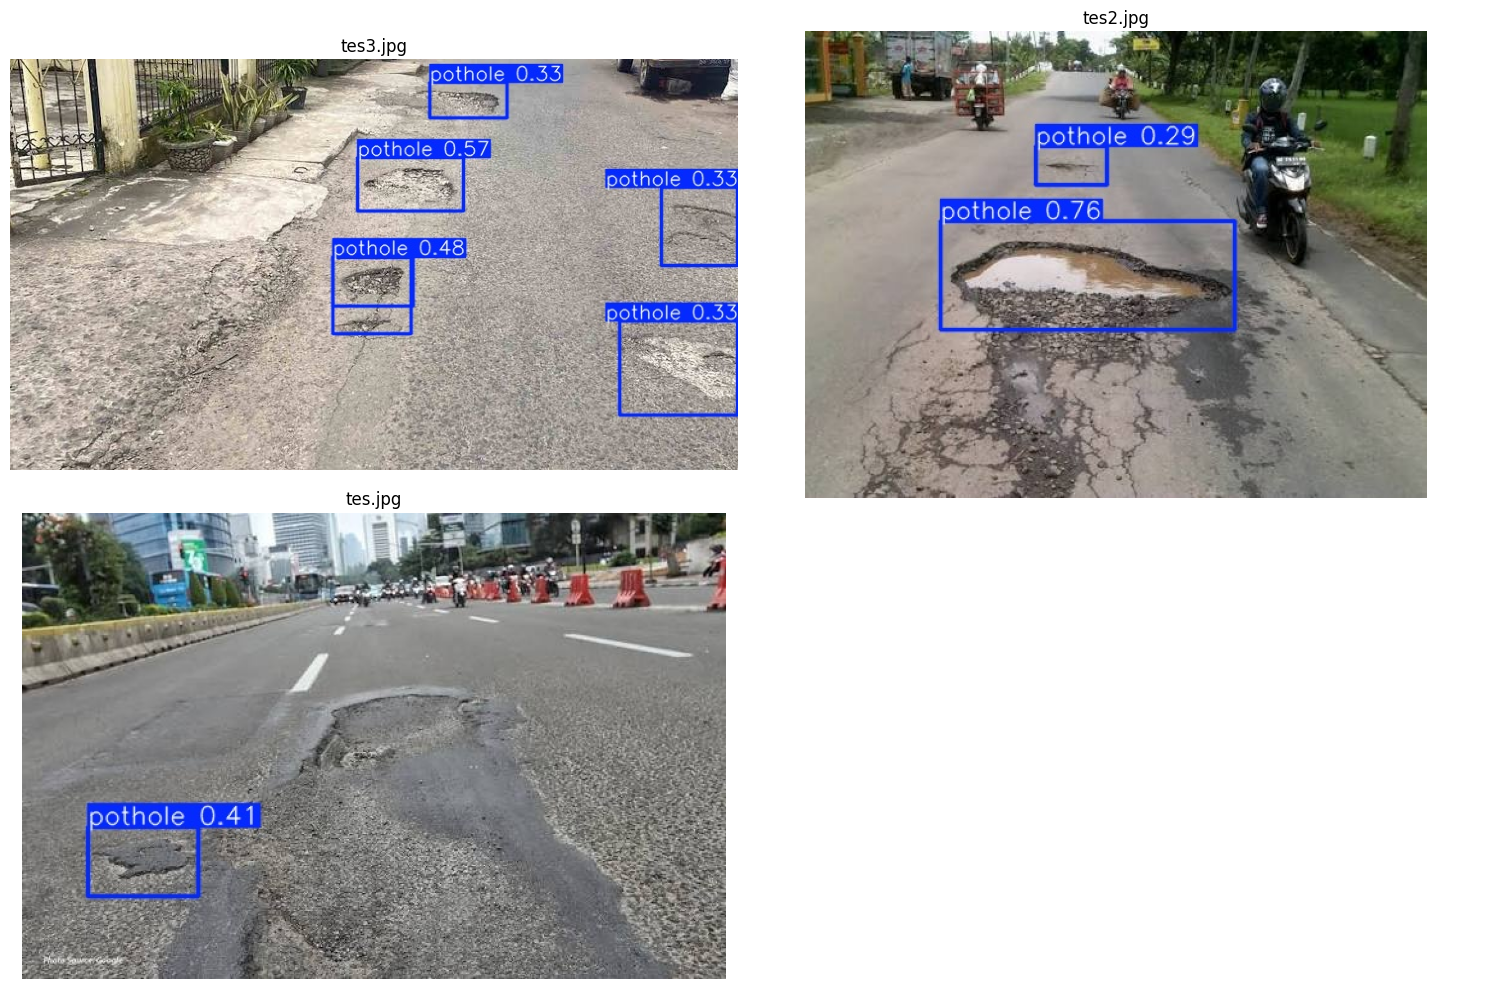

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Mencari semua file gambar hasil prediksi (TAMBAHKAN /*.jpg DI SINI)
daftar_gambar = glob.glob('/content/runs/detect/predict/*.jpg')

if len(daftar_gambar) == 0:
    print("Tidak ada gambar ditemukan. Pastikan folder jalurnya benar.")
else:
    print(f"Ditemukan {len(daftar_gambar)} gambar hasil pengujian!\n")

    # 2. Mengatur tampilan grid (Kiri - Kanan)
    jumlah_kolom = 2  # Ubah angka ini menjadi 3 jika ingin 3 gambar berjejer
    jumlah_baris = (len(daftar_gambar) + jumlah_kolom - 1) // jumlah_kolom

    # Membuat kanvas tempat gambar ditempel
    fig, axes = plt.subplots(jumlah_baris, jumlah_kolom, figsize=(15, 5 * jumlah_baris))

    # Jika gambarnya hanya 1 atau sedikit, kita pastikan bentuk 'axes' tetap bisa diolah
    if len(daftar_gambar) == 1:
        axes = [axes]
    elif jumlah_baris == 1 or jumlah_kolom == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    # 3. Menempelkan gambar satu per satu ke dalam grid
    for i, ax in enumerate(axes):
        if i < len(daftar_gambar):
            img = mpimg.imread(daftar_gambar[i])
            ax.imshow(img)

            # Menampilkan nama file di atas gambar (Opsional)
            nama_file = daftar_gambar[i].split('/')[-1]
            ax.set_title(nama_file)

            ax.axis('off') # Menghilangkan garis tepi/penggaris agar rapi
        else:
            ax.axis('off') # Menyembunyikan kotak kosong jika jumlah gambar ganjil

    plt.tight_layout()
    plt.show()